# 📈 S&P 500 Market Analysis
### Sector Performance, Financial Analysis & Stock Recommendations

This notebook:
- Downloads 10 years of S&P 500 market data from Yahoo Finance
- Shows sector performance YTD, 1Y, 2Y, 3Y
- Provides a function to fetch company financials
- Generates value-based stock recommendations using fundamental screening

## 0. Install & Import Dependencies

In [1]:
# !pip install yfinance pandas numpy matplotlib seaborn plotly requests beautifulsoup4 -q

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
import time
from datetime import datetime, timedelta
import requests

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

TODAY = datetime.today()
START_10Y = TODAY - timedelta(days=365 * 10)
START_OF_YEAR = datetime(TODAY.year, 1, 1)

print(f"Analysis date: {TODAY.strftime('%Y-%m-%d')}")
print(f"10-year window: {START_10Y.strftime('%Y-%m-%d')} → {TODAY.strftime('%Y-%m-%d')}")

Analysis date: 2026-04-05
10-year window: 2016-04-07 → 2026-04-05


## 1. S&P 500 Constituent Universe
Fetch the current S&P 500 list from Wikipedia and map tickers to GICS sectors.

In [3]:
def get_sp500_constituents():
    """Scrape current S&P 500 constituents from Wikipedia."""
    from io import StringIO

    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    # Wikipedia returns 403 for urllib's default User-Agent; use a descriptive one (see Wikimedia UA policy).
    headers = {
        "User-Agent": "fun-ml-projects/1.0 (https://github.com/yurit04/fun-ml-projects; S&P 500 notebook)",
        "Accept": "text/html,application/xhtml+xml;q=0.9,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9",
    }
    r = requests.get(url, headers=headers, timeout=60)
    r.raise_for_status()
    tables = pd.read_html(StringIO(r.text))
    df = tables[0][['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry']].copy()
    df.columns = ['ticker', 'name', 'sector', 'sub_industry']
    # Fix known ticker format issues for yfinance
    df['ticker'] = df['ticker'].str.replace('.', '-', regex=False)
    return df

sp500 = get_sp500_constituents()
print(f"S&P 500 constituents loaded: {len(sp500)} companies")
print(f"\nSector breakdown:")
print(sp500['sector'].value_counts().to_string())

S&P 500 constituents loaded: 503 companies

Sector breakdown:
sector
Industrials               79
Financials                76
Information Technology    73
Health Care               59
Consumer Discretionary    48
Consumer Staples          35
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22


## 2. Download 10 Years of Market Data
We download sector ETFs (SPDR) for efficiency, plus the SPY benchmark.

In [4]:
# SPDR Sector ETFs — proxy for each GICS sector
SECTOR_ETFS = {
    'Information Technology': 'XLK',
    'Health Care':            'XLV',
    'Financials':             'XLF',
    'Consumer Discretionary': 'XLY',
    'Communication Services': 'XLC',
    'Industrials':            'XLI',
    'Consumer Staples':       'XLP',
    'Energy':                 'XLE',
    'Utilities':              'XLU',
    'Real Estate':            'XLRE',
    'Materials':              'XLB',
}

BENCHMARK = 'SPY'
all_tickers = [BENCHMARK] + list(SECTOR_ETFS.values())

print("Downloading 10 years of daily prices for sector ETFs + SPY...")
raw = yf.download(
    all_tickers,
    start=START_10Y.strftime('%Y-%m-%d'),
    end=TODAY.strftime('%Y-%m-%d'),
    auto_adjust=True,
    progress=True
)

prices = raw['Close'].dropna(how='all')
print(f"\nPrice data shape: {prices.shape}")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")

[*********************100%***********************]  12 of 12 completed


Price data shape: (2512, 12)
Date range: 2016-04-07 → 2026-04-02


## 3. Compute Returns Over Multiple Horizons

In [5]:
def compute_period_return(prices: pd.DataFrame, start_date) -> pd.Series:
    """Return total return from start_date to the latest available price."""
    start = pd.Timestamp(start_date)
    # Find the first trading day on or after start_date
    available = prices.index[prices.index >= start]
    if len(available) == 0:
        return pd.Series(dtype=float)
    first = available[0]
    last  = prices.index[-1]
    return (prices.loc[last] / prices.loc[first] - 1) * 100

horizons = {
    'YTD':  START_OF_YEAR,
    '1Y':   TODAY - timedelta(days=365),
    '2Y':   TODAY - timedelta(days=365*2),
    '3Y':   TODAY - timedelta(days=365*3),
    '5Y':   TODAY - timedelta(days=365*5),
    '10Y':  TODAY - timedelta(days=365*10),
}

returns = pd.DataFrame(
    {label: compute_period_return(prices, start) for label, start in horizons.items()}
)

# Add sector labels
etf_to_sector = {v: k for k, v in SECTOR_ETFS.items()}
etf_to_sector[BENCHMARK] = 'S&P 500 (SPY)'
returns.index = returns.index.map(lambda x: etf_to_sector.get(x, x))
returns = returns.round(2)

print("Total Returns (%) by Sector and Horizon:")
display(returns.style
    .format("{:.1f}%")
    .background_gradient(cmap='RdYlGn', axis=0)
    .set_caption("Sector Performance (%) — SPDR ETFs vs SPY"))

Total Returns (%) by Sector and Horizon:


,YTD,1Y,2Y,3Y,5Y,10Y
Ticker,,,,,,
S&P 500 (SPY),-3.7%,31.5%,29.5%,66.4%,72.7%,277.5%
Materials,9.8%,34.1%,12.9%,33.6%,40.5%,176.9%
Communication Services,-4.1%,29.5%,38.6%,96.3%,52.7%,nan%
Energy,30.6%,56.3%,29.6%,52.5%,190.1%,185.0%
Financials,-9.4%,14.1%,22.3%,62.1%,55.1%,233.3%
Industrials,4.0%,41.4%,34.3%,73.6%,78.0%,256.6%
Information Technology,-5.6%,49.1%,33.6%,86.4%,104.1%,590.9%
Consumer Staples,6.0%,8.5%,16.3%,17.9%,35.4%,100.3%
Real Estate,3.7%,13.2%,15.1%,23.7%,21.2%,82.8%


## 4. Sector Performance Charts

In [6]:
# ── 4a. Bar chart: YTD / 1Y / 2Y / 3Y side-by-side ──────────────────────────

focus_horizons = ['YTD', '1Y', '2Y', '3Y']
df_plot = returns[focus_horizons].drop(index='S&P 500 (SPY)', errors='ignore').sort_values('YTD')

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f'{h} Total Return (%)' for h in focus_horizons],
    vertical_spacing=0.14,
    horizontal_spacing=0.08
)

color_scale = px.colors.diverging.RdYlGn

for i, horizon in enumerate(focus_horizons):
    row, col = divmod(i, 2)
    sorted_df = df_plot[horizon].sort_values()
    colors = ['#d73027' if v < 0 else '#1a9850' for v in sorted_df]
    fig.add_trace(
        go.Bar(
            x=sorted_df.values,
            y=sorted_df.index,
            orientation='h',
            marker_color=colors,
            text=[f'{v:.1f}%' for v in sorted_df],
            textposition='outside',
            showlegend=False,
            name=horizon
        ),
        row=row+1, col=col+1
    )

fig.update_layout(
    title=dict(text='S&P 500 Sector Performance by Time Horizon (SPDR ETFs)', font=dict(size=18)),
    height=800,
    paper_bgcolor='#0f1117',
    plot_bgcolor='#0f1117',
    font=dict(color='#e0e0e0', size=11),
)
fig.update_xaxes(showgrid=True, gridcolor='#2a2a2a', zerolinecolor='#555')
fig.update_yaxes(showgrid=False)
fig.show()

In [7]:
# ── 4b. Indexed cumulative performance (base = 100) over 3 years ──────────────

three_years_ago = (TODAY - timedelta(days=365*3)).strftime('%Y-%m-%d')
prices_3y = prices[prices.index >= three_years_ago].copy()

# Rebase to 100
rebased = prices_3y / prices_3y.iloc[0] * 100
rebased.columns = [etf_to_sector.get(c, c) for c in rebased.columns]

fig2 = go.Figure()
palette = px.colors.qualitative.Plotly + px.colors.qualitative.Dark24

for j, col in enumerate(rebased.columns):
    lw = 3 if col == 'S&P 500 (SPY)' else 1.5
    dash = 'solid'
    fig2.add_trace(go.Scatter(
        x=rebased.index,
        y=rebased[col],
        name=col,
        line=dict(width=lw, dash=dash, color=palette[j % len(palette)]),
        hovertemplate=f'<b>{col}</b><br>%{{x|%Y-%m-%d}}<br>%{{y:.1f}}<extra></extra>'
    ))

fig2.update_layout(
    title='3-Year Cumulative Performance — Sector ETFs vs SPY (Rebased to 100)',
    xaxis_title='Date',
    yaxis_title='Growth of $100',
    height=550,
    paper_bgcolor='#0f1117',
    plot_bgcolor='#0f1117',
    font=dict(color='#e0e0e0'),
    hovermode='x unified',
    legend=dict(orientation='v', x=1.01, y=1)
)
fig2.update_xaxes(showgrid=True, gridcolor='#2a2a2a')
fig2.update_yaxes(showgrid=True, gridcolor='#2a2a2a')
fig2.show()

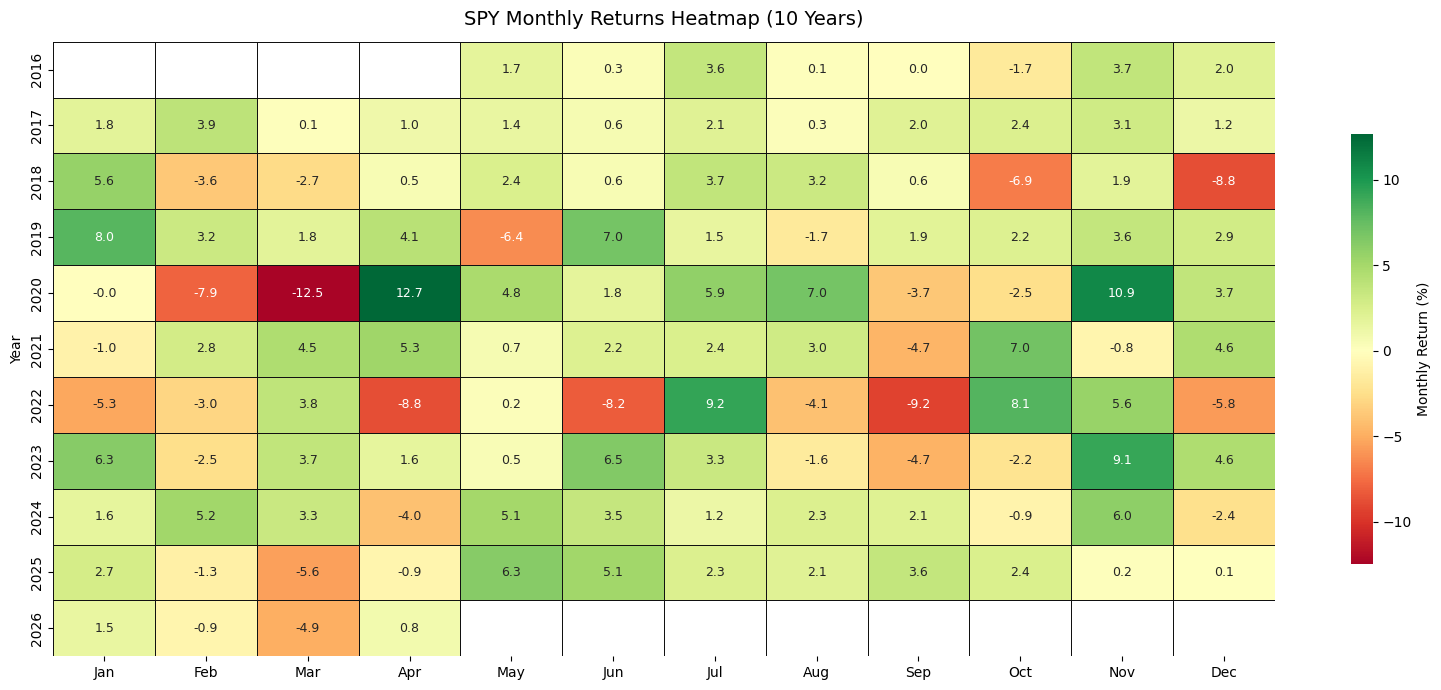

In [8]:
# ── 4c. Heat map: monthly returns for SPY ────────────────────────────────────

spy_monthly = prices['SPY'].resample('ME').last().pct_change().dropna() * 100
spy_monthly.index = spy_monthly.index.to_period('M')

pivot = spy_monthly.copy()
heat_df = pd.DataFrame({
    'year':  pivot.index.year,
    'month': pivot.index.month,
    'ret':   pivot.values
})
heat_pivot = heat_df.pivot(index='year', columns='month', values='ret')
heat_pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(16, 7))
sns.heatmap(
    heat_pivot,
    annot=True, fmt='.1f', cmap='RdYlGn', center=0,
    linewidths=0.5, linecolor='#111',
    cbar_kws={'label': 'Monthly Return (%)', 'shrink': 0.7},
    annot_kws={'size': 9}
)
plt.title('SPY Monthly Returns Heatmap (10 Years)', fontsize=14, pad=12)
plt.ylabel('Year')
plt.xlabel('')
plt.tight_layout()
plt.show()

## 5. Individual Stock Data Download

### `get_company_financials(ticker)` 
Downloads price history, balance sheet, income statement, cash flow, and key ratios for any ticker.

In [9]:
def get_company_financials(ticker: str, verbose: bool = True) -> dict:
    """
    Download comprehensive financials for a given ticker via yfinance.

    Parameters
    ----------
    ticker : str  — e.g. 'AAPL', 'MSFT'
    verbose : bool — print a summary if True

    Returns
    -------
    dict with keys:
        info            - company metadata & key ratios
        history         - 5-year daily OHLCV DataFrame
        income_stmt     - annual income statement
        balance_sheet   - annual balance sheet
        cash_flow       - annual cash flow statement
        quarterly_income_stmt
        quarterly_balance_sheet
        quarterly_cash_flow
        recommendations - analyst recommendations
        institutional_holders
        earnings_dates  - upcoming earnings calendar
    """
    t = yf.Ticker(ticker.upper())

    data = {
        'ticker':                   ticker.upper(),
        'info':                     t.info,
        'history':                  t.history(period='5y', auto_adjust=True),
        'income_stmt':              t.income_stmt,
        'balance_sheet':            t.balance_sheet,
        'cash_flow':                t.cashflow,
        'quarterly_income_stmt':    t.quarterly_income_stmt,
        'quarterly_balance_sheet':  t.quarterly_balance_sheet,
        'quarterly_cash_flow':      t.quarterly_cashflow,
        'recommendations':          t.recommendations,
        'institutional_holders':    t.institutional_holders,
        'earnings_dates':           t.earnings_dates,
    }

    if verbose:
        info = data['info']
        print(f"{'='*60}")
        print(f"  {info.get('longName', ticker)} ({ticker.upper()})")
        print(f"  Sector: {info.get('sector', 'N/A')}  |  Industry: {info.get('industry', 'N/A')}")
        print(f"{'='*60}")
        mktcap = info.get('marketCap', 0)
        print(f"  Market Cap:        ${mktcap/1e9:.1f}B")
        print(f"  Current Price:     ${info.get('currentPrice', info.get('regularMarketPrice', 'N/A'))}")
        print(f"  52W Range:         ${info.get('fiftyTwoWeekLow','N/A')} – ${info.get('fiftyTwoWeekHigh','N/A')}")
        print(f"  P/E (TTM):         {info.get('trailingPE', 'N/A')}")
        print(f"  Forward P/E:       {info.get('forwardPE', 'N/A')}")
        print(f"  P/S (TTM):         {info.get('priceToSalesTrailing12Months', 'N/A')}")
        print(f"  P/B:               {info.get('priceToBook', 'N/A')}")
        print(f"  EV/EBITDA:         {info.get('enterpriseToEbitda', 'N/A')}")
        print(f"  PEG Ratio:         {info.get('pegRatio', 'N/A')}")
        print(f"  Dividend Yield:    {(info.get('dividendYield') or 0)*100:.2f}%")
        print(f"  Revenue (TTM):     ${info.get('totalRevenue', 0)/1e9:.1f}B")
        print(f"  Net Margin:        {(info.get('profitMargins') or 0)*100:.1f}%")
        print(f"  ROE:               {(info.get('returnOnEquity') or 0)*100:.1f}%")
        print(f"  ROA:               {(info.get('returnOnAssets') or 0)*100:.1f}%")
        print(f"  Debt/Equity:       {info.get('debtToEquity', 'N/A')}")
        print(f"  Free Cash Flow:    ${info.get('freeCashflow', 0)/1e9:.1f}B")
        print(f"  Beta:              {info.get('beta', 'N/A')}")
        print(f"  Short % Float:     {(info.get('shortPercentOfFloat') or 0)*100:.1f}%")
        rec = data['recommendations']
        if rec is not None and not rec.empty:
            latest = rec.iloc[0]
            print(f"  Analyst Action:    {latest.get('Action', 'N/A')} → {latest.get('To Grade', 'N/A')} ({latest.get('Firm','N/A')})")
        print(f"{'='*60}")

    return data


# ── Example usage ─────────────────────────────────────────────────────────────
example = get_company_financials('AAPL')
print("\nAnnual Income Statement (last 4 years):")
display(example['income_stmt'].loc[['Total Revenue','Gross Profit','Net Income']].T)

  Apple Inc. (AAPL)
  Sector: Technology  |  Industry: Consumer Electronics
  Market Cap:        $3761.5B
  Current Price:     $255.92
  52W Range:         $169.21 – $288.62
  P/E (TTM):         32.35398
  Forward P/E:       27.4732
  P/S (TTM):         8.634863
  P/B:               42.667553
  EV/EBITDA:         24.727
  PEG Ratio:         N/A
  Dividend Yield:    41.00%
  Revenue (TTM):     $435.6B
  Net Margin:        27.0%
  ROE:               152.0%
  ROA:               24.4%
  Debt/Equity:       102.63
  Free Cash Flow:    $106.3B
  Beta:              1.109
  Short % Float:     0.9%
  Analyst Action:    N/A → N/A (N/A)

Annual Income Statement (last 4 years):


,Total Revenue,Gross Profit,Net Income
2025-09-30,416161000000.00,195201000000.00,112010000000.00
2024-09-30,391035000000.00,180683000000.00,93736000000.00
2023-09-30,383285000000.00,169148000000.00,96995000000.00
2022-09-30,394328000000.00,170782000000.00,99803000000.00
2021-09-30,NaN,NaN,NaN


## 6. Value Screen — Which Stocks Look Cheap?

We screen the full S&P 500 universe using a multi-factor value framework:

| Factor | Weight | Rationale |
|--------|--------|-----------|
| Forward P/E vs sector median | 25% | Core earnings cheapness |
| EV/EBITDA vs sector median | 20% | Capital-structure-neutral multiple |
| P/S vs sector median | 15% | Avoids earnings manipulation |
| PEG ratio | 15% | Adjusts for growth |
| P/B vs sector median | 10% | Asset cheapness |
| Free Cash Flow Yield | 15% | Quality + value signal |

In [10]:
def fetch_fundamentals_batch(tickers: list, delay: float = 0.05) -> pd.DataFrame:
    """
    Fetch key valuation metrics for a list of tickers.
    Returns a DataFrame with one row per ticker.
    """
    records = []
    n = len(tickers)
    for i, ticker in enumerate(tickers):
        if i % 50 == 0:
            print(f"  Progress: {i}/{n} tickers...")
        try:
            info = yf.Ticker(ticker).info
            records.append({
                'ticker':          ticker,
                'name':            info.get('shortName', ticker),
                'sector':          info.get('sector', 'Unknown'),
                'market_cap':      info.get('marketCap', np.nan),
                'forward_pe':      info.get('forwardPE', np.nan),
                'trailing_pe':     info.get('trailingPE', np.nan),
                'ev_ebitda':       info.get('enterpriseToEbitda', np.nan),
                'ps_ratio':        info.get('priceToSalesTrailing12Months', np.nan),
                'pb_ratio':        info.get('priceToBook', np.nan),
                'peg_ratio':       info.get('pegRatio', np.nan),
                'fcf':             info.get('freeCashflow', np.nan),
                'market_cap_raw':  info.get('marketCap', np.nan),
                'net_margin':      info.get('profitMargins', np.nan),
                'roe':             info.get('returnOnEquity', np.nan),
                'debt_equity':     info.get('debtToEquity', np.nan),
                'dividend_yield':  info.get('dividendYield', 0) or 0,
                'beta':            info.get('beta', np.nan),
                'price':           info.get('currentPrice', info.get('regularMarketPrice', np.nan)),
                '52w_low':         info.get('fiftyTwoWeekLow', np.nan),
                '52w_high':        info.get('fiftyTwoWeekHigh', np.nan),
            })
        except Exception:
            pass
        time.sleep(delay)

    df = pd.DataFrame(records)
    # Compute FCF yield = FCF / market cap
    df['fcf_yield'] = df['fcf'] / df['market_cap_raw']
    # % distance from 52W high (lower = more beaten down)
    df['pct_from_52w_high'] = (df['price'] / df['52w_high'] - 1) * 100
    return df


print("Fetching fundamentals for S&P 500 constituents (this takes 3–5 minutes)...")
tickers = sp500['ticker'].tolist()
fundamentals = fetch_fundamentals_batch(tickers)
print(f"\nFetched data for {len(fundamentals)} companies")
fundamentals.head(3)

Fetching fundamentals for S&P 500 constituents (this takes 3–5 minutes)...
  Progress: 0/503 tickers...
  Progress: 50/503 tickers...
  Progress: 100/503 tickers...
  Progress: 150/503 tickers...
  Progress: 200/503 tickers...
  Progress: 250/503 tickers...
  Progress: 300/503 tickers...
  Progress: 350/503 tickers...
  Progress: 400/503 tickers...
  Progress: 450/503 tickers...
  Progress: 500/503 tickers...

Fetched data for 503 companies


,ticker,name,sector,market_cap,forward_pe,trailing_pe,ev_ebitda,ps_ratio,pb_ratio,peg_ratio,fcf,market_cap_raw,net_margin,roe,debt_equity,dividend_yield,beta,price,52w_low,52w_high,fcf_yield,pct_from_52w_high
0,MMM,3M Company,Industrials,76092350464,15.39,24.08,13.52,3.05,16.29,NaN,1260249984.00,76092350464,0.13,0.76,276.64,2.16,1.16,144.47,121.98,177.41,0.02,-18.57
1,AOS,A.O. Smith Corporation,Industrials,8898956288,14.80,16.71,10.96,2.32,4.80,NaN,426162496.00,8898956288,0.14,0.29,10.97,2.18,1.35,64.35,58.83,81.87,0.05,-21.40
2,ABT,Abbott Laboratories,Healthcare,178755452928,16.85,27.65,15.34,4.03,3.43,NaN,6288999936.00,178755452928,0.15,0.13,26.79,2.45,0.78,102.87,100.88,139.06,0.04,-26.02


In [11]:
def compute_value_scores(df: pd.DataFrame) -> pd.DataFrame:
    """
    Score each stock on value metrics vs its sector peers.
    Lower multiple → higher score (cheaper).
    FCF yield is inverted (higher yield → higher score).
    Final composite score is 0–100 (higher = cheaper / better value).
    """
    df = df.copy()

    # ── 1. Sector-relative z-scores for valuation multiples ──
    valuation_cols = ['forward_pe', 'ev_ebitda', 'ps_ratio', 'pb_ratio', 'peg_ratio']
    yield_col = 'fcf_yield'

    for col in valuation_cols + [yield_col]:
        sector_med = df.groupby('sector')[col].transform('median')
        sector_std = df.groupby('sector')[col].transform('std').replace(0, np.nan)
        df[f'z_{col}'] = (df[col] - sector_med) / sector_std

    # ── 2. Composite: low multiples = cheap, high FCF yield = cheap ──
    # Negate multiple z-scores (low P/E → high score)
    WEIGHTS = {
        'forward_pe':  0.25,
        'ev_ebitda':   0.20,
        'ps_ratio':    0.15,
        'peg_ratio':   0.15,
        'pb_ratio':    0.10,
        'fcf_yield':   0.15,   # positive: high yield = cheap
    }

    composite = pd.Series(0.0, index=df.index)
    for col, w in WEIGHTS.items():
        z = df[f'z_{col}']
        if col == 'fcf_yield':
            contrib = w * z          # higher yield → higher score
        else:
            contrib = w * (-z)       # lower multiple → higher score
        # One NaN z (e.g. missing peg_ratio from yfinance) used to poison the entire row.
        composite = composite + contrib.fillna(0)

    # ── 3. Scale to 0–100 ──
    mn, mx = composite.min(), composite.max()
    span = mx - mn
    if not np.isfinite(span) or span == 0:
        df['value_score'] = 50.0
    else:
        df['value_score'] = ((composite - mn) / span * 100).round(1)

    # ── 4. Quality filter: exclude deeply negative ROE or very high debt ──
    df['quality_pass'] = (
        (df['roe'].fillna(0) > -0.10) &
        (df['debt_equity'].fillna(999) < 200) &
        (df['net_margin'].fillna(0) > -0.05)
    )

    return df


scored = compute_value_scores(fundamentals)
print("Value scoring complete.")

Value scoring complete.


In [12]:
# ── Top value picks: quality-filtered, min $5B market cap, positive FCF ──────

MIN_MKTCAP = 5e9   # $5B minimum

screened = scored[
    scored['quality_pass'] &
    (scored['market_cap_raw'] >= MIN_MKTCAP) &
    (scored['fcf'].fillna(0) > 0) &
    (scored['forward_pe'].notna()) &
    (scored['forward_pe'] > 0)
].copy()

top_value = screened.sort_values('value_score', ascending=False).head(25)

display_cols = [
    'ticker', 'name', 'sector',
    'price', 'pct_from_52w_high',
    'forward_pe', 'ev_ebitda', 'ps_ratio', 'pb_ratio', 'peg_ratio',
    'fcf_yield', 'net_margin', 'roe', 'dividend_yield',
    'value_score'
]

display_df = top_value[display_cols].rename(columns={
    'pct_from_52w_high': '% from 52W Hi',
    'forward_pe':        'Fwd P/E',
    'ev_ebitda':         'EV/EBITDA',
    'ps_ratio':          'P/S',
    'pb_ratio':          'P/B',
    'peg_ratio':         'PEG',
    'fcf_yield':         'FCF Yield',
    'net_margin':        'Net Margin',
    'roe':               'ROE',
    'dividend_yield':    'Div Yield',
    'value_score':       'Value Score'
})

print("\n📋 Top 25 Value Opportunities in the S&P 500")
print("(Quality-filtered: +FCF, +ROE, manageable debt, market cap > $5B)\n")

display(display_df.set_index('ticker').style
    .format({
        'price':          '${:.2f}',
        '% from 52W Hi':  '{:.1f}%',
        'Fwd P/E':        '{:.1f}x',
        'EV/EBITDA':      '{:.1f}x',
        'P/S':            '{:.1f}x',
        'P/B':            '{:.1f}x',
        'PEG':            '{:.2f}',
        'FCF Yield':      '{:.1%}',
        'Net Margin':     '{:.1%}',
        'ROE':            '{:.1%}',
        'Div Yield':      '{:.2%}',
        'Value Score':    '{:.1f}',
    })
    .background_gradient(subset=['Value Score'], cmap='YlGn')
    .background_gradient(subset=['Fwd P/E'], cmap='RdYlGn_r')
    .background_gradient(subset=['FCF Yield'], cmap='YlGn')
    .set_caption("Value Score: 0=expensive, 100=cheapest vs sector peers")
)


📋 Top 25 Value Opportunities in the S&P 500
(Quality-filtered: +FCF, +ROE, manageable debt, market cap > $5B)



,name,sector,price,% from 52W Hi,Fwd P/E,EV/EBITDA,P/S,P/B,PEG,FCF Yield,Net Margin,ROE,Div Yield,Value Score
ticker,,,,,,,,,,,,,,
GPN,Global Payments Inc.,Industrials,$64.05,-29.6%,3.9x,9.5x,2.3x,0.7x,nan,9.8%,18.2%,4.8%,156.00%,82.1
SWK,"Stanley Black & Decker, Inc.",Industrials,$68.64,-26.5%,10.8x,9.9x,0.7x,1.2x,nan,8.0%,2.7%,4.5%,484.00%,77.8
DAL,"Delta Air Lines, Inc.",Industrials,$66.76,-12.6%,8.1x,7.8x,0.7x,2.1x,nan,6.8%,7.9%,27.7%,112.00%,77.6
BLDR,"Builders FirstSource, Inc.",Industrials,$79.12,-47.6%,10.3x,9.9x,0.6x,2.0x,nan,7.1%,2.9%,10.1%,0.00%,77.0
PSKY,Paramount Skydance Corporation,Communication Services,$9.52,-54.4%,10.1x,8.9x,0.4x,0.9x,nan,149.7%,-2.1%,-0.9%,210.00%,76.8
CI,The Cigna Group,Healthcare,$270.02,-22.9%,8.1x,7.8x,0.3x,1.7x,nan,13.5%,2.2%,15.1%,231.00%,75.5
APA,APA Corporation,Energy,$42.04,-7.9%,12.1x,3.9x,1.7x,2.4x,nan,13.2%,16.5%,25.3%,238.00%,75.3
ES,Eversource Energy (D/B/A),Utilities,$69.47,-9.1%,13.6x,12.0x,1.9x,1.6x,nan,2.9%,12.5%,10.8%,453.00%,74.9
UPS,"United Parcel Service, Inc.",Industrials,$98.18,-19.8%,12.3x,8.7x,0.9x,5.1x,nan,6.2%,6.3%,33.8%,668.00%,74.0


In [13]:
# ── Bubble chart: Value Score vs FCF Yield, sized by market cap ──────────────
# Keep only rows that have finite x/y/size inputs, then take top 50 by score
# (sorting first and then dropna() can yield an empty frame if high scorers lack FCF yield).

plot_ready = screened.replace([np.inf, -np.inf], np.nan).dropna(
    subset=['value_score', 'fcf_yield', 'forward_pe']
)
plot_ready = plot_ready[
    np.isfinite(plot_ready['fcf_yield'])
    & np.isfinite(plot_ready['forward_pe'])
    & np.isfinite(plot_ready['market_cap_raw'])
]
top50 = plot_ready.sort_values('value_score', ascending=False).head(50)

if top50.empty:
    print(
        "Value Map skipped: no screened stocks with finite value_score, FCF yield, "
        "forward P/E, and market cap. Re-run fundamentals fetch or relax MIN_MKTCAP / filters."
    )
else:
    fig3 = px.scatter(
        top50,
        x='fcf_yield',
        y='forward_pe',
        size='market_cap_raw',
        color='sector',
        text='ticker',
        hover_data={'name': True, 'value_score': True, 'net_margin': ':.1%', 'roe': ':.1%'},
        size_max=50,
        title='Value Map: FCF Yield vs Forward P/E — Top 50 Value Candidates',
        labels={
            'fcf_yield':   'FCF Yield (higher = better value)',
            'forward_pe':  'Forward P/E (lower = cheaper)',
        },
        template='plotly_dark'
    )

    fig3.update_traces(textposition='top center', textfont=dict(size=9))
    fig3.update_layout(
        height=600,
        paper_bgcolor='#0f1117',
        plot_bgcolor='#0f1117',
        font=dict(color='#e0e0e0'),
    )
    # Invert y-axis: lower P/E at top
    fig3.update_yaxes(autorange='reversed')
    fig3.show()

In [14]:
# ── Value picks by sector ─────────────────────────────────────────────────────

top_by_sector = (
    screened
    .sort_values('value_score', ascending=False)
    .groupby('sector')
    .head(3)
    .sort_values(['sector', 'value_score'], ascending=[True, False])
)

print("\n🏆 Top 3 Value Picks Per Sector\n")
print(f"{'Sector':<28} {'Ticker':<8} {'Name':<35} {'Fwd P/E':>8} {'EV/EBT':>8} "
      f"{'FCF Yld':>8} {'ROE':>7} {'Score':>7}")
print("-" * 115)

current_sector = None
for _, row in top_by_sector.iterrows():
    sector_label = row['sector'] if row['sector'] != current_sector else ''
    current_sector = row['sector']
    fpe   = f"{row['forward_pe']:.1f}x" if pd.notna(row['forward_pe']) else 'N/A'
    eve   = f"{row['ev_ebitda']:.1f}x"  if pd.notna(row['ev_ebitda'])  else 'N/A'
    fcfy  = f"{row['fcf_yield']:.1%}"   if pd.notna(row['fcf_yield'])  else 'N/A'
    roe   = f"{row['roe']:.1%}"         if pd.notna(row['roe'])        else 'N/A'
    print(f"{sector_label:<28} {row['ticker']:<8} {row['name'][:34]:<35} "
          f"{fpe:>8} {eve:>8} {fcfy:>8} {roe:>7} {row['value_score']:>7.1f}")


🏆 Top 3 Value Picks Per Sector

Sector                       Ticker   Name                                 Fwd P/E   EV/EBT  FCF Yld     ROE   Score
-------------------------------------------------------------------------------------------------------------------
Basic Materials              IFF      International Flavors & Fragran        15.1x    13.2x    16.7%   -2.6%    69.0
                             PPG      PPG Industries, Inc.                   11.9x    10.9x     2.3%   21.1%    68.8
                             CRH      CRH PLC                                15.8x    11.6x     2.6%   15.7%    65.7
Communication Services       PSKY     Paramount Skydance Corporation         10.1x     8.9x   149.7%   -0.9%    76.8
                             CMCSA    Comcast Corporation                     7.2x     5.3x     5.5%   21.4%    65.4
                             OMC      Omnicom Group Inc.                      6.0x    10.2x    19.4%    0.5%    64.9
Consumer Cyclical            APT

## 7. Deep-Dive: Get Full Financials on a Specific Stock
Use `get_company_financials()` defined in Section 5 to pull complete data on any name.

In [15]:
# ── Change TICKER to any S&P 500 name you want to examine ────────────────────
TICKER = 'GOOGL'   # <─── edit me

data = get_company_financials(TICKER)

# Plot 5-year price + volume
hist = data['history']

fig4 = make_subplots(rows=2, cols=1, shared_xaxes=True,
                     row_heights=[0.75, 0.25], vertical_spacing=0.04)

fig4.add_trace(go.Scatter(
    x=hist.index, y=hist['Close'],
    name='Price', line=dict(color='#00d4aa', width=1.5)
), row=1, col=1)

fig4.add_trace(go.Bar(
    x=hist.index, y=hist['Volume'],
    name='Volume', marker_color='#4488ff', opacity=0.5
), row=2, col=1)

fig4.update_layout(
    title=f"{data['info'].get('longName', TICKER)} — 5-Year Price & Volume",
    height=500,
    paper_bgcolor='#0f1117',
    plot_bgcolor='#0f1117',
    font=dict(color='#e0e0e0'),
    showlegend=False
)
fig4.update_xaxes(showgrid=True, gridcolor='#2a2a2a')
fig4.update_yaxes(showgrid=True, gridcolor='#2a2a2a')
fig4.show()

  Alphabet Inc. (GOOGL)
  Sector: Communication Services  |  Industry: Internet Content & Information
  Market Cap:        $3577.9B
  Current Price:     $295.77
  52W Range:         $140.53 – $349.0
  P/E (TTM):         27.38611
  Forward P/E:       22.023607
  P/S (TTM):         8.881852
  P/B:               8.609728
  EV/EBITDA:         23.427
  PEG Ratio:         N/A
  Dividend Yield:    28.00%
  Revenue (TTM):     $402.8B
  Net Margin:        32.8%
  ROE:               35.7%
  ROA:               15.4%
  Debt/Equity:       16.133
  Free Cash Flow:    $38.1B
  Beta:              1.128
  Short % Float:     1.4%
  Analyst Action:    N/A → N/A (N/A)


In [16]:
# ── Annual financials summary ─────────────────────────────────────────────────
is_ = data['income_stmt']
bs_ = data['balance_sheet']
cf_ = data['cash_flow']

key_rows_is = [r for r in ['Total Revenue', 'Gross Profit', 'Operating Income',
                             'Net Income', 'EBITDA'] if r in is_.index]
key_rows_bs = [r for r in ['Total Assets', 'Total Debt', 'Stockholders Equity',
                             'Cash And Cash Equivalents'] if r in bs_.index]
key_rows_cf = [r for r in ['Operating Cash Flow', 'Free Cash Flow', 'Capital Expenditure'] if r in cf_.index]

print(f"\n── Income Statement (Annual, $M) ──")
display((is_.loc[key_rows_is] / 1e6).round(0).T.style.format('{:,.0f}'))

print(f"\n── Balance Sheet (Annual, $M) ──")
display((bs_.loc[key_rows_bs] / 1e6).round(0).T.style.format('{:,.0f}'))

print(f"\n── Cash Flow (Annual, $M) ──")
display((cf_.loc[key_rows_cf] / 1e6).round(0).T.style.format('{:,.0f}'))


── Income Statement (Annual, $M) ──


,Total Revenue,Gross Profit,Operating Income,Net Income,EBITDA
2025-12-31 00:00:00,"402,836","240,301","129,039","132,170","180,698"
2024-12-31 00:00:00,"350,018","203,712","112,390","100,118","135,394"
2023-12-31 00:00:00,"307,394","174,062","84,293","73,795","97,971"
2022-12-31 00:00:00,"282,836","156,633","74,842","59,972","85,160"
2021-12-31 00:00:00,nan,nan,nan,nan,nan



── Balance Sheet (Annual, $M) ──


,Total Assets,Total Debt,Stockholders Equity,Cash And Cash Equivalents
2025-12-31 00:00:00,"595,281","59,291","415,265","30,708"
2024-12-31 00:00:00,"450,256","22,574","325,084","23,466"
2023-12-31 00:00:00,"402,392","27,121","283,379","24,048"
2022-12-31 00:00:00,"365,264","29,679","256,144","21,879"
2021-12-31 00:00:00,nan,nan,nan,nan



── Cash Flow (Annual, $M) ──


,Operating Cash Flow,Free Cash Flow,Capital Expenditure
2025-12-31 00:00:00,"164,713","73,266","-91,447"
2024-12-31 00:00:00,"125,299","72,764","-52,535"
2023-12-31 00:00:00,"101,746","69,495","-32,251"
2022-12-31 00:00:00,"91,495","60,010","-31,485"
2021-12-31 00:00:00,nan,nan,nan


## 8. Summary Dashboard

In [17]:
# ── Final summary: best value ideas with investment thesis tags ───────────────

print("\n" + "="*70)
print("  📊 S&P 500 VALUE OPPORTUNITIES — SUMMARY")
print(f"  As of {TODAY.strftime('%B %d, %Y')}")
print("="*70)
print("""
METHODOLOGY NOTE
━━━━━━━━━━━━━━━
The Value Score ranks stocks on 6 metrics vs. sector peers:
  • Forward P/E (25%)  • EV/EBITDA (20%)  • P/S (15%)
  • PEG ratio (15%)    • P/B (10%)        • FCF Yield (15%)

Stocks passing quality filters (positive FCF, ROE > -10%,
D/E < 200%, net margin > -5%, market cap > $5B) are ranked.

⚠️  DISCLAIMER: This is a quantitative screen, not financial
advice. Always conduct your own due diligence. Past performance
and model scores do not guarantee future returns.
""")

top5 = screened.sort_values('value_score', ascending=False).head(5)
print("TOP 5 OVERALL VALUE PICKS:")
print("-"*70)
for rank, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  #{rank}  {row['ticker']:<6}  {row['name']:<35}  Score: {row['value_score']:.0f}/100")
    print(f"        {row['sector']}")
    metrics = []
    if pd.notna(row['forward_pe']):  metrics.append(f"Fwd P/E {row['forward_pe']:.1f}x")
    if pd.notna(row['ev_ebitda']):   metrics.append(f"EV/EBITDA {row['ev_ebitda']:.1f}x")
    if pd.notna(row['fcf_yield']):   metrics.append(f"FCF Yield {row['fcf_yield']:.1%}")
    if pd.notna(row['roe']):         metrics.append(f"ROE {row['roe']:.1%}")
    print(f"        {' | '.join(metrics)}")
    print()

print("="*70)
print("Run get_company_financials(ticker) for a full deep-dive on any name.")
print("="*70)


  📊 S&P 500 VALUE OPPORTUNITIES — SUMMARY
  As of April 05, 2026

METHODOLOGY NOTE
━━━━━━━━━━━━━━━
The Value Score ranks stocks on 6 metrics vs. sector peers:
  • Forward P/E (25%)  • EV/EBITDA (20%)  • P/S (15%)
  • PEG ratio (15%)    • P/B (10%)        • FCF Yield (15%)

Stocks passing quality filters (positive FCF, ROE > -10%,
D/E < 200%, net margin > -5%, market cap > $5B) are ranked.

⚠️  DISCLAIMER: This is a quantitative screen, not financial
advice. Always conduct your own due diligence. Past performance
and model scores do not guarantee future returns.

TOP 5 OVERALL VALUE PICKS:
----------------------------------------------------------------------
  #1  GPN     Global Payments Inc.                 Score: 82/100
        Industrials
        Fwd P/E 3.9x | EV/EBITDA 9.5x | FCF Yield 9.8% | ROE 4.8%

  #2  SWK     Stanley Black & Decker, Inc.         Score: 78/100
        Industrials
        Fwd P/E 10.8x | EV/EBITDA 9.9x | FCF Yield 8.0% | ROE 4.5%

  #3  DAL     Delta Air Lin